# Import Libraries

In [4]:
import numpy as np               # For handling large, multi-dimensional arrays and matrices.
import pandas as pd              # For data manipulation and analysis (used to read CSV files).
import matplotlib.pyplot as plt  # For creating visualizations like accuracy/loss graphs.
import cv2                       # OpenCV: used for computer vision and image processing.
import tensorflow as tf          # The core framework for building and training neural networks.
from PIL import Image            # Python Imaging Library: used to open and resize images.
import os 
from sklearn.model_selection import train_test_split # Helper to split data into training/testing sets.
from keras.utils import to_categorical # Converts class labels into one-hot encoded vectors.
from keras.models import Sequential, load_model # Classes to define a linear stack of layers.
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization  # The building blocks of the CNN.
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# VISUALIZING DATA DISTRIBUTION

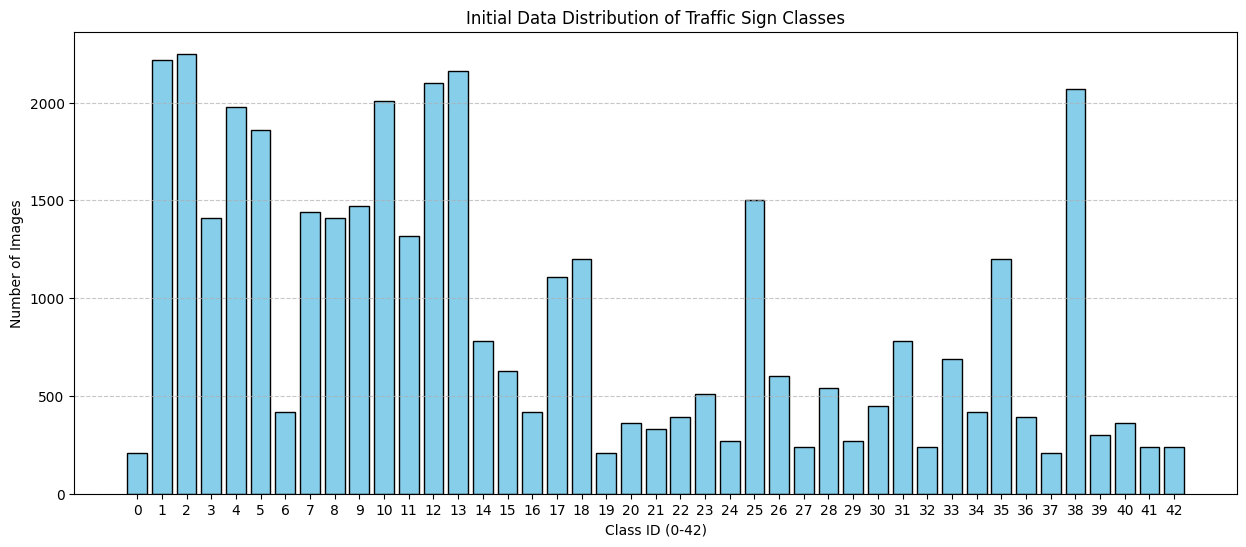

In [5]:
train_path = os.path.join(os.getcwd(), 'data', 'Train')
folders = os.listdir(train_path)

# Dictionary to store counts
class_counts = []
class_names = []

for folder in range(43):
    path = os.path.join(train_path, str(folder))
    images = os.listdir(path)
    class_counts.append(len(images))
    class_names.append(folder)

# Plotting the distribution
plt.figure(figsize=(15, 6))
plt.bar(class_names, class_counts, color='skyblue', edgecolor='black')
plt.xlabel('Class ID (0-42)')
plt.ylabel('Number of Images')
plt.title('Initial Data Distribution of Traffic Sign Classes')
plt.xticks(range(0, 43))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Data Preparation and Preprocessing

In [6]:
data = []     # Empty list to store the pixel data of every image.
labels = []   # Empty list to store the category ID (0-42) for each image.
classes = 43  # The total number of unique traffic sign types in the dataset.
cur_path = os.getcwd() # Gets the current path 

In [7]:
# Create CLAHE object once to reuse for all images (more efficient than creating it inside the loop)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# function to apply CLAHE to an image array
def apply_clahe(image_array):
    """Apply CLAHE to each RGB channel separately to fix uneven lighting."""
    channels = cv2.split(image_array)               # Split into R, G, B
    equalized = [clahe.apply(ch) for ch in channels] # Apply CLAHE per channel
    return cv2.merge(equalized)                      # Merge back together

# Loop through each class folder, read and preprocess images, and store them with their labels.
for i in range(classes):
    path = os.path.join(cur_path, 'data', 'Train', str(i))
    images = os.listdir(path)
    for a in images:
        try:
            image = Image.open(os.path.join(path, a))
            image = image.resize((64, 64)) # Resize to 64x64 pixels for uniformity and to reduce computational load.
            image = np.array(image)
            image = apply_clahe(image)   # Here we apply CLAHE to correct for uneven lighting conditions in the images.         
            data.append(image)
            labels.append(i)
        except Exception as e:
            print(e)

## Converting lists into numpy arrays

In [8]:
data = np.array(data)
labels = np.array(labels)

## Normalizing pixel values to a range of 0 to 1

In [9]:
data = data.astype('float32') / 255.0 # Normalize pixel values to [0, 1] range for better training performance.

In [10]:
print(data.shape, labels.shape)

(39209, 64, 64, 3) (39209,)


# Save Labels & Data for future use

In [11]:
if not os.path.exists('training'):
    os.mkdir('training')

np.save('./training/data', data)
np.save('./training/target', labels)

# DATA SPLITTING & AUGMENTATION

In [12]:
# DATA SPLIT STRATEGY:
# We split the Train folder 80/20 → X_train (80%) is used for training,
# X_test (20%) is used as validation_data during model.fit() to monitor
# overfitting and trigger callbacks (EarlyStopping, ReduceLROnPlateau).
#
# The true final evaluation is done separately on Test.csv which has path details to Test data(testing() function),
# which is completely held-out data the model never sees during training.
# This gives an unbiased measure of real-world performance.

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=0)

y_train_raw = y_train.copy()   # integer labels  e.g. [0, 2, 5, 41 ...] // changed
y_test = to_categorical(y_test, 43) #y_test one-hot encoded here, y_train encoded AFTER oversampling

# Creating a generator to artificially expand the dataset
aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15, 
    fill_mode="nearest"
)

# TARGETED OVERSAMPLING FOR RARE CLASSES

Target count per class: 467
Class 27: has 193, generating 274 more...
Class 29: has 212, generating 255 more...
Class 41: has 186, generating 281 more...
Class 23: has 411, generating 56 more...
Class 32: has 201, generating 266 more...
Class 39: has 235, generating 232 more...
Class 30: has 349, generating 118 more...
Class 40: has 289, generating 178 more...
Class 20: has 286, generating 181 more...
Class 22: has 313, generating 154 more...
Class 34: has 348, generating 119 more...
Class 28: has 415, generating 52 more...
Class 0: has 169, generating 298 more...
Class 36: has 317, generating 150 more...
Class 37: has 161, generating 306 more...
Class 6: has 332, generating 135 more...
Class 42: has 195, generating 272 more...
Class 21: has 261, generating 206 more...
Class 24: has 203, generating 264 more...
Class 16: has 329, generating 138 more...
Class 19: has 176, generating 291 more...

Before oversampling: 31367 images
After oversampling:  35593 images


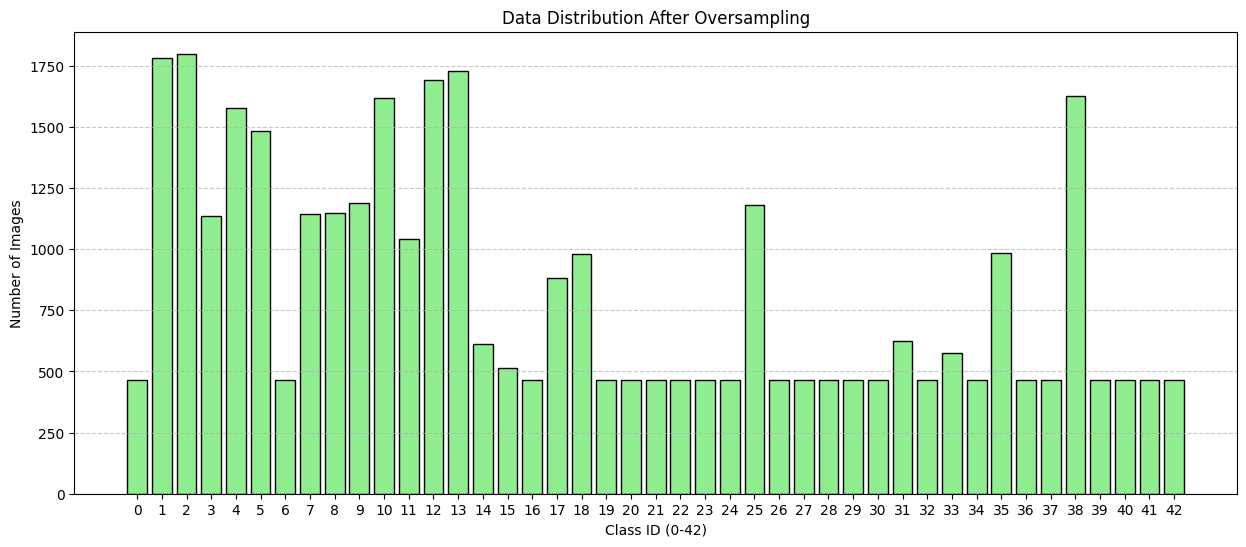

In [13]:
class_counts_dict = Counter(y_train_raw)

# Target the median count to avoid inflating dataset too much
target_count = int(np.median(list(class_counts_dict.values())))
print(f"Target count per class: {target_count}")

X_balanced = list(X_train)
y_balanced = list(y_train_raw)

for class_id, count in class_counts_dict.items():
    if count < target_count:
        needed = target_count - count
        print(f"Class {class_id}: has {count}, generating {needed} more...")

        # Get all images of this rare class
        class_images = X_train[y_train_raw == class_id]

        # Generate needed extras using augmentation
        generated = 0
        for batch in aug.flow(class_images, batch_size=1):
            X_balanced.append(batch[0])
            y_balanced.append(class_id)
            generated += 1
            if generated >= needed:
                break

X_balanced = np.array(X_balanced)
y_balanced = np.array(y_balanced)

print(f"\nBefore oversampling: {len(X_train)} images")
print(f"After oversampling:  {len(X_balanced)} images")

# One-hot encode AFTER oversampling
y_balanced_cat = to_categorical(y_balanced, 43)

# Optional: visualize new distribution
new_counts = Counter(y_balanced)
plt.figure(figsize=(15, 6))
plt.bar(new_counts.keys(), new_counts.values(), color='lightgreen', edgecolor='black')
plt.xlabel('Class ID (0-42)')
plt.ylabel('Number of Images')
plt.title('Data Distribution After Oversampling')
plt.xticks(range(0, 43))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# CNN ARCHITECTURE

In [14]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(BatchNormalization())  
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))
model.add(BatchNormalization())   
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())   
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())   
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())   
model.add(Dropout(rate=0.5))
model.add(Dense(43, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 60, 60, 32)        2432      
                                                                 
 batch_normalization (BatchN  (None, 60, 60, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 56, 56, 32)        25632     
                                                                 
 batch_normalization_1 (Batc  (None, 56, 56, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 28, 28, 32)       0         
 )                                                               
                                                        

# TRAINING WITH AUGMENTATION 

In [15]:
batch_size = 32
epochs = 35  
# function for training the model with callbacks for better performance and to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,                  # stops if no improvement for 5 epochsIs ht
    restore_best_weights=True    # rolls back to the best epoch automatically
)
# function to reduce learning rate when the model is stuck (plateau) to help it escape local minima and converge better
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # halves the learning rate when stuck
    patience=3,      # waits 3 epochs before reducing
    min_lr=1e-6,
    verbose=1        # prints a message when LR is reduced
)

history = model.fit(
    aug.flow(X_balanced, y_balanced_cat, batch_size=batch_size),
    validation_data=(X_test, y_test),
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)

model.save("./training/TSR_Augmented.h5")

Epoch 1/35
1113/1113 [==============================] - 108s 68ms/step - loss: 1.1432 - accuracy: 0.6722 - val_loss: 0.2014 - val_accuracy: 0.9385 - lr: 0.0010
Epoch 2/35
1113/1113 [==============================] - 73s 65ms/step - loss: 0.3228 - accuracy: 0.9037 - val_loss: 0.2398 - val_accuracy: 0.9249 - lr: 0.0010
Epoch 3/35
1113/1113 [==============================] - 124s 111ms/step - loss: 0.1812 - accuracy: 0.9469 - val_loss: 0.0335 - val_accuracy: 0.9913 - lr: 0.0010
Epoch 4/35
1113/1113 [==============================] - 90s 80ms/step - loss: 0.1326 - accuracy: 0.9609 - val_loss: 0.0710 - val_accuracy: 0.9795 - lr: 0.0010
Epoch 5/35
1113/1113 [==============================] - 71s 64ms/step - loss: 0.1103 - accuracy: 0.9672 - val_loss: 0.0164 - val_accuracy: 0.9959 - lr: 0.0010
Epoch 6/35
1113/1113 [==============================] - 73s 66ms/step - loss: 0.0967 - accuracy: 0.9702 - val_loss: 0.0293 - val_accuracy: 0.9912 - lr: 0.0010
Epoch 7/35
1113/1113 [=====================

# TESTING

In [16]:
def testing(testcsv):
    y_test_df = pd.read_csv(testcsv)
    labels = y_test_df["ClassId"].values
    imgs = y_test_df["Path"].values
    data_list = []

    for img in imgs:
        image_path = os.path.join('data', img)
        image = Image.open(image_path)
        image = image.resize((64, 64))
        image = np.array(image)
        image = apply_clahe(image)                  
        data_list.append(image)

    X_test_data = np.array(data_list)
    return X_test_data.astype('float32') / 255.0, labels

# UPDATED: Path changed to 'data/Test.csv'
X_test_final, label_actual = testing('data/Test.csv') 

Y_pred = np.argmax(model.predict(X_test_final, batch_size=32), axis=-1)

from sklearn.metrics import accuracy_score, classification_report
print("Final Augmented Test Accuracy:", accuracy_score(label_actual, Y_pred))

395/395 [==============================] - 8s 16ms/step
Final Augmented Test Accuracy: 0.9916072842438638


# Classification Report 

In [17]:
print("\nPer-class report:")
print(classification_report(label_actual, Y_pred, digits=3))


Per-class report:
              precision    recall  f1-score   support

           0      0.952     1.000     0.976        60
           1      0.999     1.000     0.999       720
           2      0.993     0.999     0.996       750
           3      0.998     0.978     0.988       450
           4      0.995     0.991     0.993       660
           5      0.983     0.994     0.988       630
           6      0.993     0.933     0.962       150
           7      0.985     0.996     0.990       450
           8      0.991     0.980     0.985       450
           9      0.996     0.998     0.997       480
          10      0.997     0.998     0.998       660
          11      1.000     0.995     0.998       420
          12      1.000     0.977     0.988       690
          13      0.996     0.999     0.997       720
          14      1.000     1.000     1.000       270
          15      0.938     1.000     0.968       210
          16      1.000     1.000     1.000       150
        

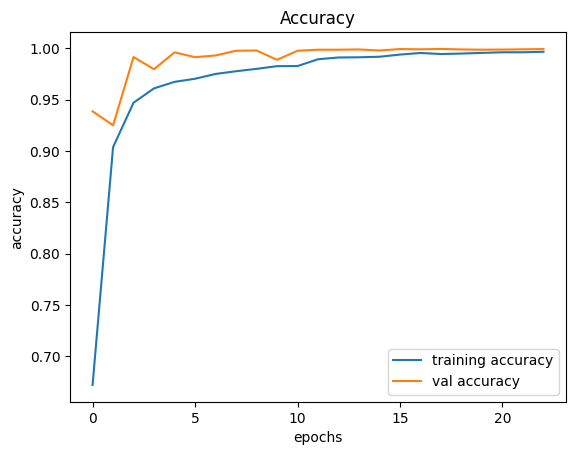

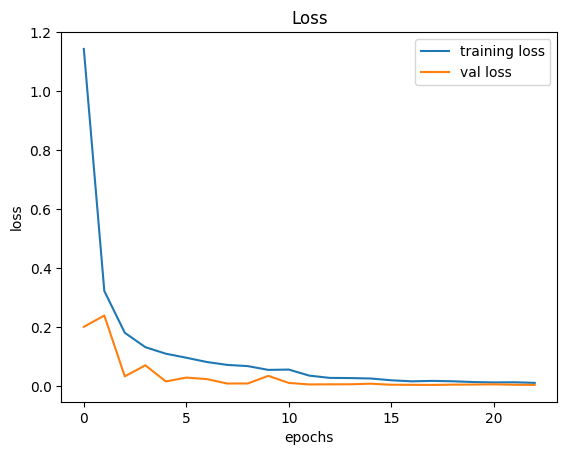

In [18]:
# --- SECTION 6: PLOTTING PERFORMANCE ---

# Accuracy plot
plt.figure(0)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

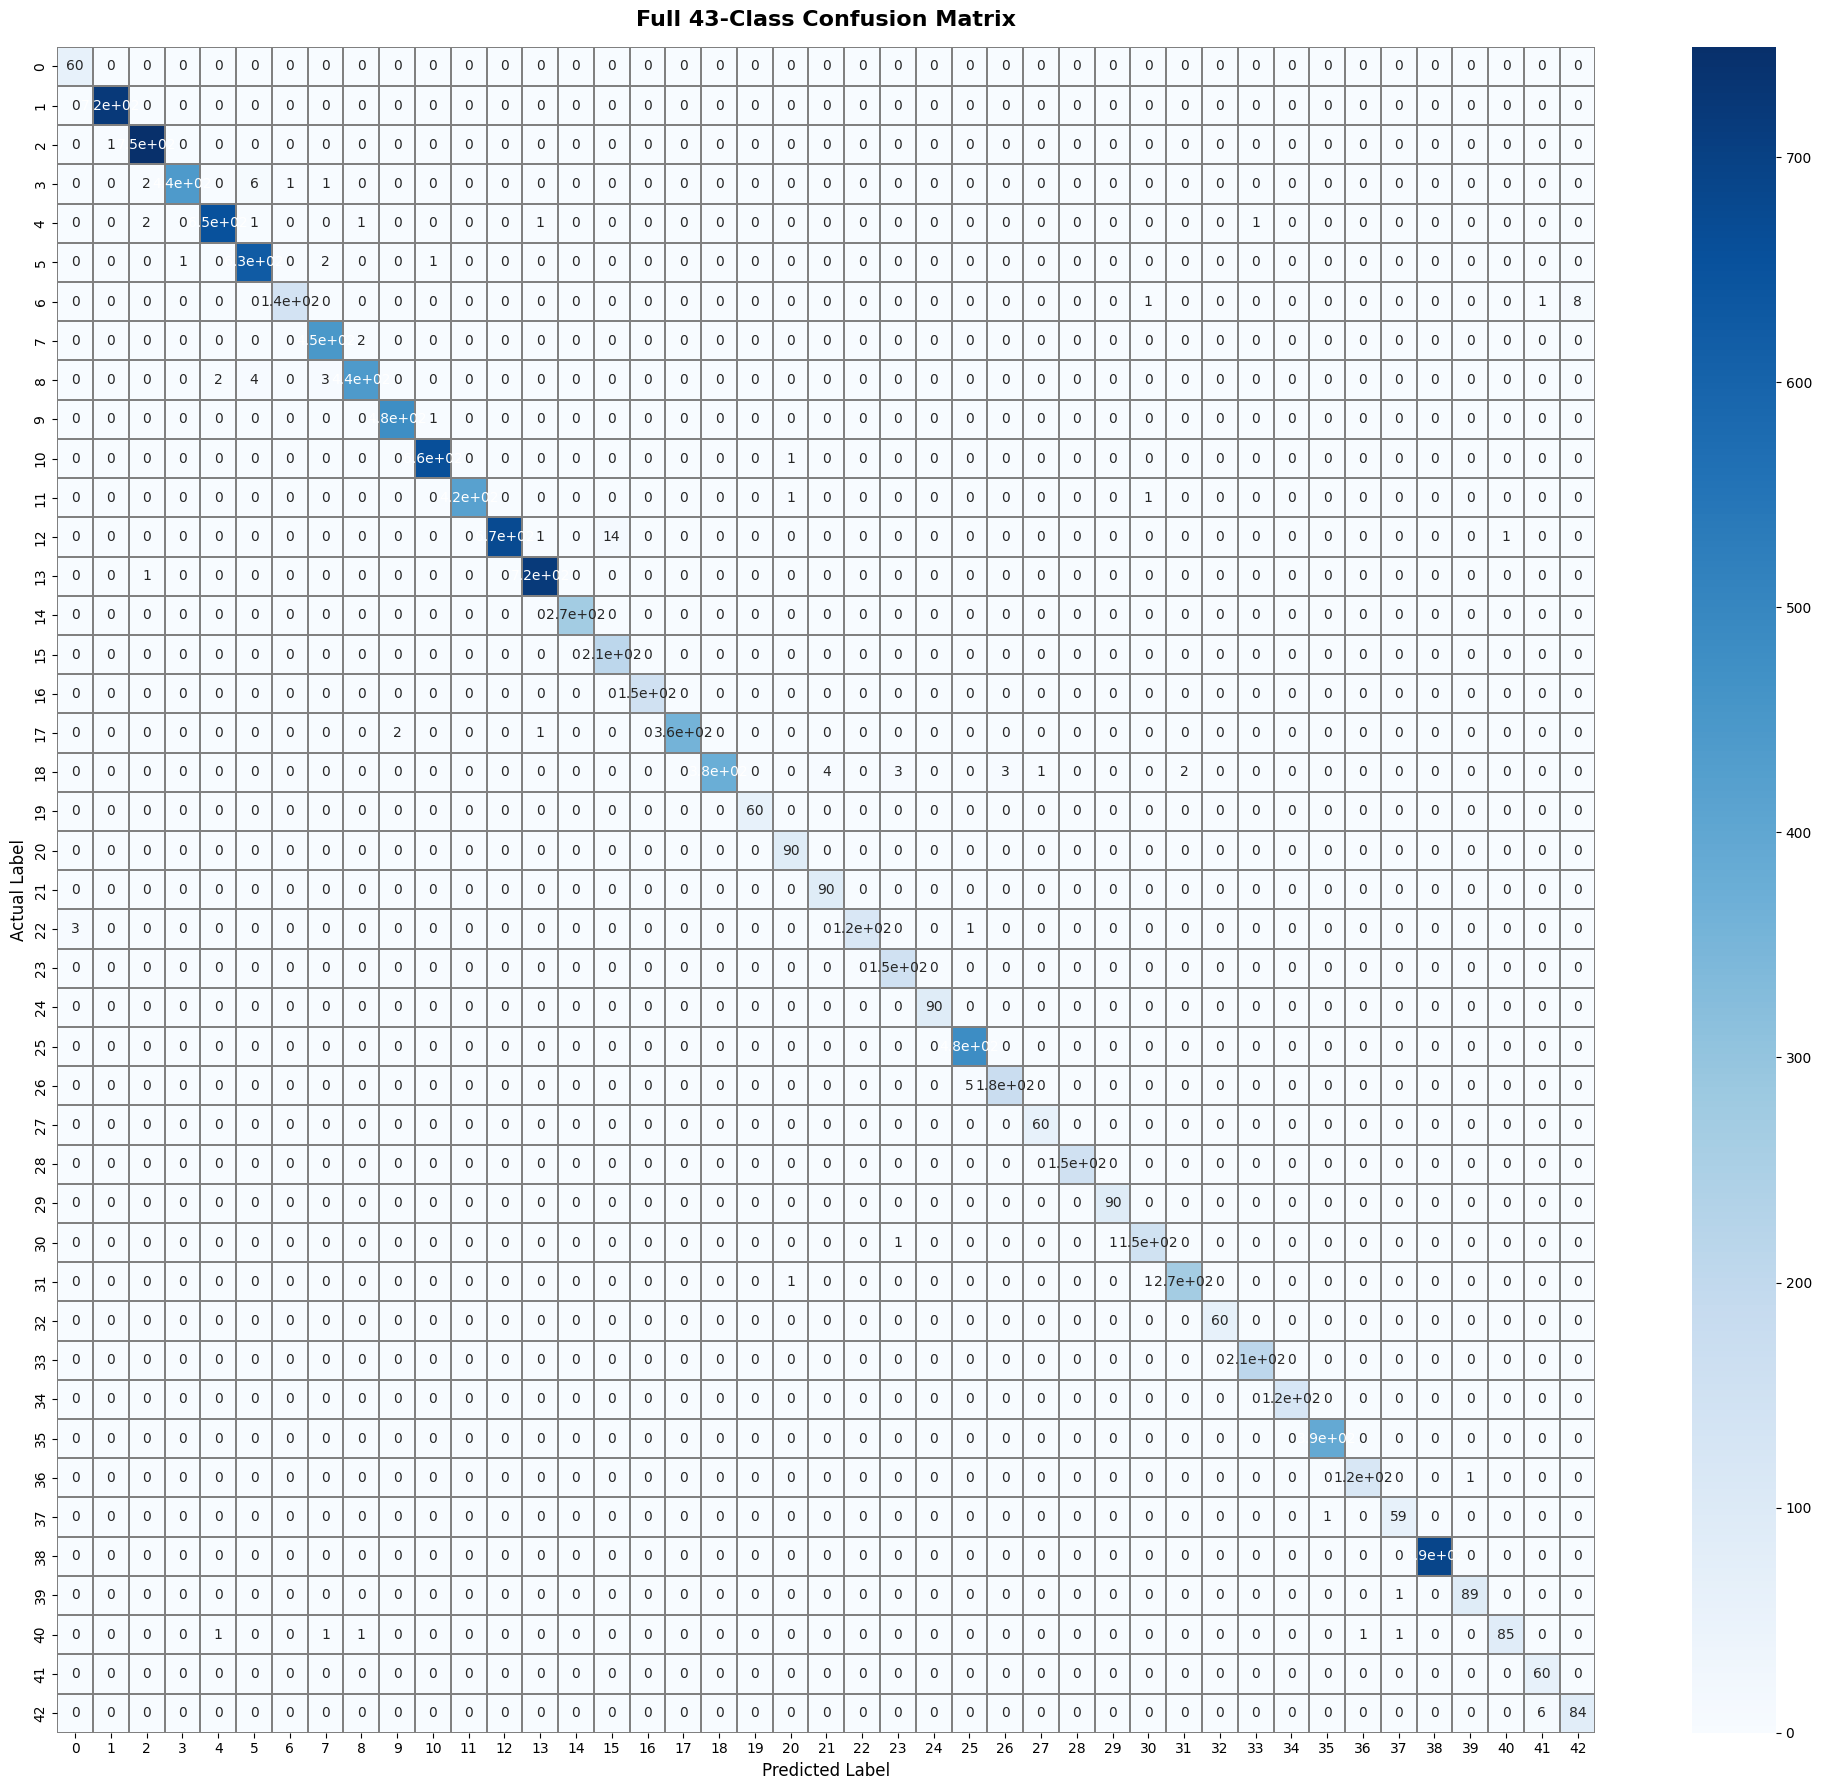

Top 10 Most Confused Pairs (Actual → Predicted):
--------------------------------------------------
  Actual: 12 (Priority road            ) → Predicted: 15 (No entry                 ) | 14 times
  Actual:  6 (Speed limit end 80       ) → Predicted: 42 (Turn left                ) | 8 times
  Actual:  3 (Speed limit 60           ) → Predicted:  5 (Speed limit 80           ) | 6 times
  Actual: 42 (Turn left                ) → Predicted: 41 (Turn right               ) | 6 times
  Actual: 26 (Steep climb              ) → Predicted: 25 (Steep descent            ) | 5 times
  Actual:  8 (Speed limit 120          ) → Predicted:  5 (Speed limit 80           ) | 4 times
  Actual: 18 (No entry both            ) → Predicted: 21 (Dangerous right          ) | 4 times
  Actual:  8 (Speed limit 120          ) → Predicted:  7 (Speed limit 100          ) | 3 times
  Actual: 18 (No entry both            ) → Predicted: 23 (Bumpy road               ) | 3 times
  Actual: 18 (No entry both            ) → P

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Map ClassId to traffic sign descriptions (GTSRB dataset)
classes_dict = {
    0: 'Speed limit 20', 1: 'Speed limit 30', 2: 'Speed limit 50', 3: 'Speed limit 60', 4: 'Speed limit 70',
    5: 'Speed limit 80', 6: 'Speed limit end 80', 7: 'Speed limit 100', 8: 'Speed limit 120', 9: 'No passing',
    10: 'No passing trucks', 11: 'Right of way', 12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No entry',
    16: 'Prohibited', 17: 'Prohibited trucks', 18: 'No entry both', 19: 'Caution', 20: 'Dangerous left', 
    21: 'Dangerous right', 22: 'Dangerous curve', 23: 'Bumpy road', 24: 'Slippery', 25: 'Steep descent',
    26: 'Steep climb', 27: 'Keep right', 28: 'Keep left', 29: 'Roundabout', 30: 'End no passing', 
    31: 'End no passing trucks', 32: 'Speed limit 80 end', 33: 'Speed limit 100 end', 34: 'Speed limit 120 end',
    35: 'Pedestrian crossing', 36: 'Children crossing', 37: 'Bicycle crossing', 38: 'Ice/snow', 39: 'Wildlife',
    40: 'End restrictions', 41: 'Turn right', 42: 'Turn left'
}

# Full 43-class confusion matrix
cm_full = confusion_matrix(label_actual, Y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm_full,
    annot=True,        # Turn off numbers — 43x43 is too dense to read
    cmap='Blues',
    linewidths=0.3,
    linecolor='gray',
    xticklabels=range(43),
    yticklabels=range(43)
)
plt.title('Full 43-Class Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Top 10 most confused pairs (more useful than staring at a dense heatmap)
print("Top 10 Most Confused Pairs (Actual → Predicted):")
print("-" * 50)
cm_copy = cm_full.copy()
np.fill_diagonal(cm_copy, 0)  # ignore correct predictions

for i in range(10):
    idx = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    count = cm_copy[idx]
    if count == 0:
        break
    print(f"  Actual: {idx[0]:2d} ({classes_dict[idx[0]][:25]:25s}) → "
          f"Predicted: {idx[1]:2d} ({classes_dict[idx[1]][:25]:25s}) | {count} times")
    cm_copy[idx] = 0


In [20]:
# Generate report as dictionary
report = classification_report(label_actual, Y_pred, digits=3, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Drop summary rows (accuracy, macro avg, weighted avg)
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Convert index to integer class IDs and map to sign names
report_df.index = report_df.index.astype(int)
report_df['sign_name'] = report_df.index.map(classes_dict)

# Sort by f1-score to find worst performers
worst = report_df.sort_values('f1-score').head(10)

print("=" * 70)
print("TOP 10 WORST PERFORMING CLASSES")
print("=" * 70)
print(f"{'Class':>6} | {'Sign Name':<30} | {'Precision':>9} | {'Recall':>6} | {'F1':>6} | {'Support':>7}")
print("-" * 70)
for class_id, row in worst.iterrows():
    print(f"{class_id:>6} | {row['sign_name']:<30} | {row['precision']:>9.3f} | {row['recall']:>6.3f} | {row['f1-score']:>6.3f} | {int(row['support']):>7}")
print("=" * 70)

TOP 10 WORST PERFORMING CLASSES
 Class | Sign Name                      | Precision | Recall |     F1 | Support
----------------------------------------------------------------------
    42 | Turn left                      |     0.913 |  0.933 |  0.923 |      90
    41 | Turn right                     |     0.896 |  1.000 |  0.945 |      60
     6 | Speed limit end 80             |     0.993 |  0.933 |  0.962 |     150
    40 | End restrictions               |     0.988 |  0.944 |  0.966 |      90
    15 | No entry                       |     0.938 |  1.000 |  0.968 |     210
    37 | Bicycle crossing               |     0.967 |  0.983 |  0.975 |      60
     0 | Speed limit 20                 |     0.952 |  1.000 |  0.976 |      60
    26 | Steep climb                    |     0.983 |  0.972 |  0.978 |     180
    21 | Dangerous right                |     0.957 |  1.000 |  0.978 |      90
    22 | Dangerous curve                |     1.000 |  0.967 |  0.983 |     120
